In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# plotting parameters
plt.rc('axes', labelsize=10)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)

plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'
paper_params = {'text.usetex' : True,
           'font.size' : 14,
           'font.family' : 'lmodern',
           'figure.dpi' : 200,
           }
plt.rcParams.update(paper_params)
## 3.5 x 3 inch figure size for single column in paper
## 7 x 3 inch figure size for two column in paper


In [ ]:
# planet mass = 1 earth mass
# planet radius = 1 earth radius
R_Earth = 6.3781e+6 # m
M_Earth = 1 # Earth masses
R_planet = 6378100.0 * M_Earth ** 0.27
R_planet

6378100.0

In [29]:
# read the Urey Ratio files and data
data_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/test_Urey_ratio/'

In [30]:
time, Q_crust, Q_mantle = np.genfromtxt(data_dir+'Total_Heat_Production.dat', unpack=True)

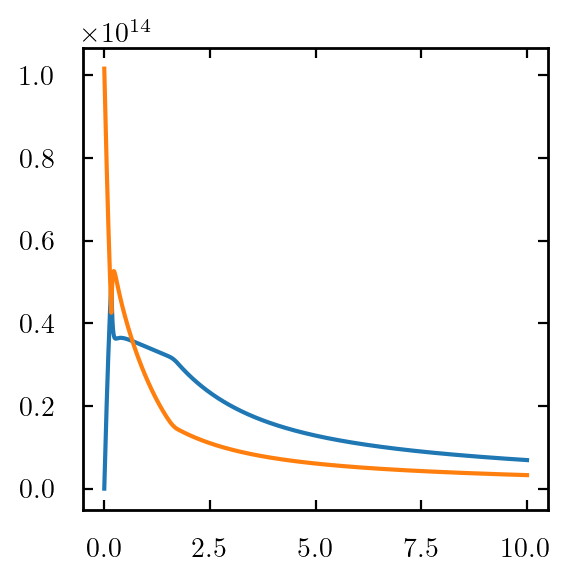

In [31]:
fig, ax = plt.subplots(1,1,figsize=(3,3),dpi=200)

ax.plot(time, Q_crust)
ax.plot(time, Q_mantle)

In [32]:
time, conv_heat_flux, mag_heat_flux, crust_heat_flux = np.genfromtxt(data_dir+'Earth_heat_fluxWm2.dat', unpack=True)

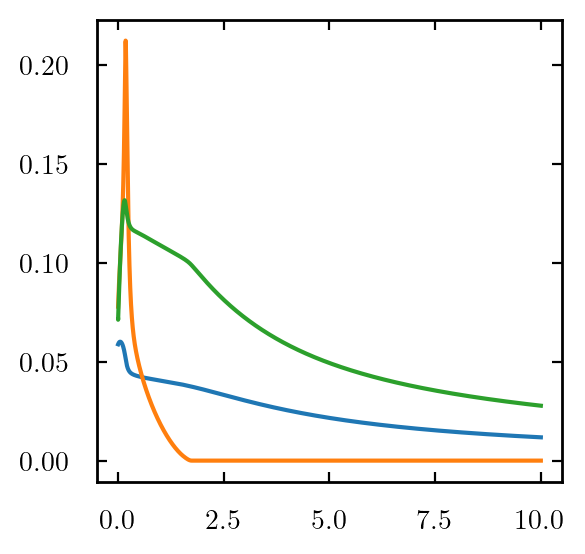

In [33]:
fig, ax = plt.subplots(1,1,figsize=(3,3),dpi=200)

ax.plot(time, conv_heat_flux)
ax.plot(time, mag_heat_flux)
ax.plot(time, crust_heat_flux)

In [34]:
# total heat production 
Q_total = Q_crust + Q_mantle
Q_surf_loss = (mag_heat_flux + crust_heat_flux) * 4 * np.pi * R_planet**2

Text(0, 0.5, 'U ($Q_\\mathrm{prod} / Q_\\mathrm{lost}$)')

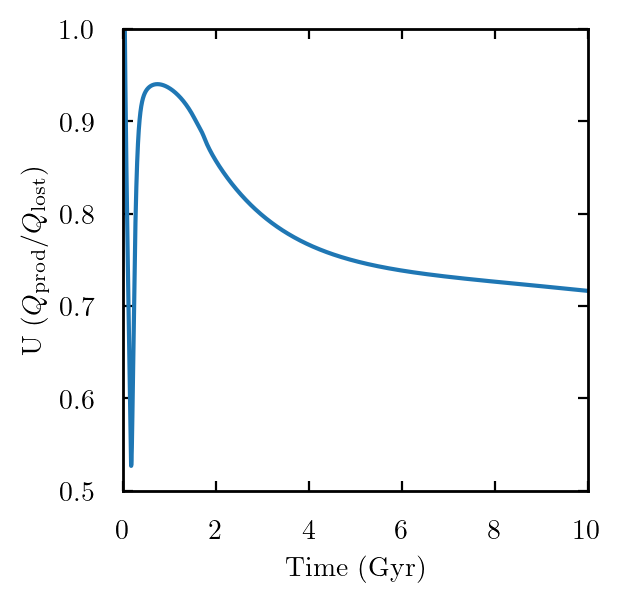

In [37]:
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=200)
ax.plot(time, (Q_total / Q_surf_loss))
ax.set_ylim(0.5, 1.0)
ax.set_xlim(min(time), max(time))
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'U ($Q_\mathrm{prod} / Q_\mathrm{lost}$)')

In [27]:
radiogenic_mass_sweep_dir = '/Users/dimoff/Radiogenic_Heating/planet_models/thermal_evolution_Foley_Unterborn/mass_sweep_radiogenic/'
list_files = !ls {radiogenic_mass_sweep_dir}*heat_production*.dat

masses = []
concentrations = []
times = []
qs_crust = []; qs_mantle = []

for file in list_files:
    mass = float(file.split('_')[-3].split('m')[0])
    concentration = float(file.split('_')[-2])
    masses.append(mass)
    concentrations.append(concentration)
    # read the files
    time, q_crust, q_mantle = np.genfromtxt(file, unpack=True)
    # append data to lists
    times.append(time)
    qs_crust.append(q_mantle)
    qs_mantle.append(q_crust)

#times = np.array(times); conv_heat_fluxes = np.array(conv_heat_fluxes); mag_heat_fluxes = np.array(mag_heat_fluxes); surf_heat_fluxes = np.array(surf_heat_fluxes)
masses = np.array(masses); concentrations = np.array(concentrations)
unique_masses = np.unique(masses); unique_concentrations = np.unique(concentrations)

print(f"Unique masses: {unique_masses}")
print(f"Unique concentrations: {unique_concentrations}")

Unique masses: [0.1 0.2 0.3 0.4]
Unique concentrations: [0.00e+00 2.00e-01 4.00e-01 6.00e-01 8.00e-01 1.00e+00 1.25e+00 1.50e+00
 2.00e+00 3.00e+00 4.00e+00 5.00e+00 6.00e+00 7.00e+00 8.00e+00 9.00e+00
 1.00e+01 1.50e+01 2.00e+01 3.00e+01 4.00e+01 5.00e+01 6.00e+01 7.00e+01
 8.00e+01 9.00e+01 1.00e+02 1.20e+02 1.40e+02 1.50e+02 1.75e+02 2.00e+02
 3.00e+02 4.00e+02 5.00e+02]
